# Data Science Project 2: Fraud Detection Pipeline
### DecodeLabs Internship — Week 2

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split 
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

## 2. Loading the Dataset

In [2]:
df = pd.read_csv("creditcard.csv")

## 3. Exploratory Data Analysis (EDA)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [7]:
df["Class"].value_counts(normalize = True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

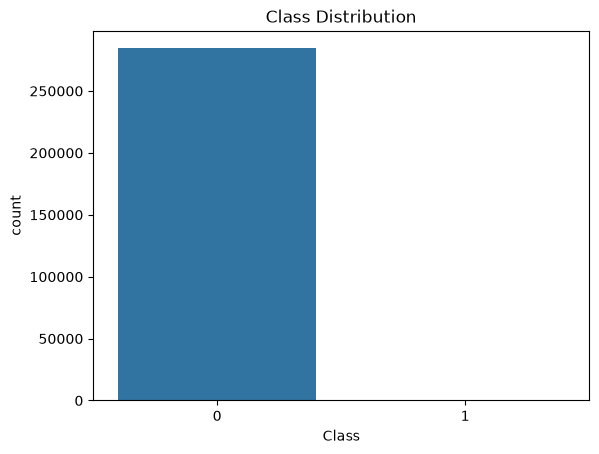

In [8]:
sns.countplot(x = "Class", data = df)
plt.title("Class Distribution")
plt.show()

In [9]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

## 4. Feature-Target Split & Train/Test Split
Splitting the dataset into features (X) and target (y), then performing a stratified train/test split before applying SMOTE to prevent data leakage.

In [10]:
X = df.drop("Class", axis = 1)
y = df["Class"]

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

In [12]:
y_train.value_counts(normalize = True) * 100

Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64

In [13]:
y_test.value_counts(normalize = True) * 100

Class
0    99.827955
1     0.172045
Name: proportion, dtype: float64

## 5. Building Pipelines (Scaler -> SMOTE -> Model)

In [14]:
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(random_state=42))
])

In [15]:
pipeline_lr.fit(X_train, y_train)

,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](30,)","['Time','V1','V2',...,'V27','V28','Amount']"
n_features_in_,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [16]:
pipeline_rf = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [17]:
pipeline_rf.fit(X_train, y_train)

,steps,"[('smote', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](30,)","['Time','V1','V2',...,'V27','V28','Amount']"
n_features_in_,int,30
,random_state,42
,sampling_strategy,'auto'
,k_neighbors,5


In [18]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_lr = pipeline_lr.predict(X_test)
y_pred_rf = pipeline_rf.predict(X_test)

## 6. Model Evaluation (Logistic Regression vs Random Forest)

In [19]:
print("Logistic Regression Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [20]:
print("Random Forest Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [21]:
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Logistic Regression Confusion Matrix:
[[55397  1467]
 [    8    90]]

Random Forest Confusion Matrix:
[[56848    16]
 [   17    81]]


In [22]:
y_proba_lr = pipeline_lr.predict_proba(X_test)[:, 1]
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, y_proba_lr))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

Logistic Regression ROC-AUC: 0.9708434302252134
Random Forest ROC-AUC: 0.9644232605112952


## 7. Hyperparameter Tuning with GridSearchCV

In [28]:
param_grid = {
    "classifier__n_estimators": [100],
    "classifier__max_depth": [10,20],
    "smote__k_neighbors": [3]
}

In [29]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    pipeline_rf,
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

In [30]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 2 candidates, totalling 6 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [10, 20], 'classifier__n_estimators': [100], 'smote__k_neighbors': [3]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_gr

In [31]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'classifier__max_depth': 20, 'classifier__n_estimators': 100, 'smote__k_neighbors': 3}
0.845860326282744


## 8. Final Model Evaluation (Tuned Random Forest)

In [32]:
best_model = grid_search.best_estimator_
y_pred_final = best_model.predict(X_test)
y_proba_final = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_final))
print(confusion_matrix(y_test, y_pred_final))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_final))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.85      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

[[56846    18]
 [   15    83]]
ROC-AUC: 0.9613155053805427


## 9. Conclusion

This project pushed me to go beyond just training a model the real challenge was handling an extremely imbalanced dataset (99.83% legitimate vs 0.17% fraud) without falling into common traps like data leakage or trusting misleading accuracy scores.

I trained two models, Logistic Regression and Random Forest, both wrapped in an imblearn pipeline so that SMOTE was applied only on the training folds, never touching the test set.

The results were eye-opening. Logistic Regression caught almost all fraud cases (92 percent recall), but at a huge cost, nearly 1,467 legitimate transactions were wrongly flagged as fraud. In a real banking system, that means thousands of genuine customers getting blocked or harassed over false alarms, which isn't something I'd want to ship.

Random Forest, on the other hand, struck a much better balance, around 82 to 85 percent precision and recall, with far fewer false positives, just 16 to 18 compared to LR's 1,467. I also ran GridSearchCV to tune the SMOTE and Random Forest parameters together, but interestingly, the tuned model performed almost identically to the untuned one, just with a slightly different precision-recall trade-off.

Given the choice, I'd go with Random Forest, even if it means missing a few more fraud cases, protecting genuine customers from false flags matters more for trust and long-term business relationships. This project really drove home why accuracy alone means nothing on imbalanced data, and why precision-recall trade-offs are a business decision, not just a technical one.

Final Metrics (Random Forest): ROC-AUC around 0.96, F1-score around 0.83